# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Rizki Pangestu
- **Email:** cdcc183d6y2123@student.devacademy.id
- **ID Dicoding:** cdcc183d6y2123

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Bagaimana perbedaan pola jumlah rata-rata penyewaan sepeda antara pengguna kasual dan pengguna terdaftar pada hari kerja dibandingkan dengan hari libur/akhir pekan selama periode tahun 2012?
- **Pertanyaan 2:** Seberapa besar persentase penurunan rata-rata jumlah total penyewaan sepeda harian saat kondisi cuaca sedang hujan/bersalju  dibandingkan saat cuaca cerahsecara keseluruhan pada tahun 2011 hingga 2012
- **Pertanyaan 3:** "Pada jam berapa saja terjadi puncak penyewaan sepeda tertinggi oleh pengguna terdaftar khusus pada hari kerja  selama periode musim gugur di tahun 2012?

## Import Semua Packages/Library yang Digunakan

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [51]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Data Wrangling

### Gathering Data

#### Load df ...

In [52]:
df_datahour = pd.read_csv ('/content/drive/MyDrive/DataMentah/hour.csv')
df_datahour.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [53]:
df_datahour.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [54]:
df_dataday = pd.read_csv ('/content/drive/MyDrive/DataMentah/day.csv')
df_dataday.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [55]:
df_dataday.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


**Insight:** (Opsional)
- Pada Dataset hour.csv terdapat informasi data persewaan sepeda harian dengan 17 kolom data dan 17.379 data persewaan sepeda
- Pada Dataset hour.csv terdapat informasi data persewaan sepeda per jam terdapat 16 kolom data dan 731 data persewaan sepeda
- dari hasil informasi data tersebut terdapat hampir semua kolom yang ada memiliki kemiripan yang sama terdapat kolom hr(jam) pada data hour.csv sedangkan data day.csv tidak memiliki kolom

**Deskripsi Variabel Dataset**
Berikut penjelasan setiap kolom :
- **instant** : Nomor urut setiap baris data.
- **dteday** : Tanggal pencatatan data dalam format YYYY-MM-DD.
- **season** : Musim saat pencatatan. (1 = Semi, 2 = Panas, 3 = Gugur, 4 = Dingin)
- **yr** : Tahun pencatatan. (0 = 2011, 1 = 2012)
- **mnth** : Bulan pencatatan, bernilai 1 hingga 12.
- **hr** : Jam pencatatan dalam sehari, bernilai 0 hingga 23. (Hanya tersedia di hour.csv)
- **holiday** : Menunjukkan apakah hari tersebut merupakan hari libur nasional. (0 = Bukan libur, 1 = Hari libur)
- **weekday** : Hari dalam seminggu. (0 = Minggu, 1 = Senin, ..., 6 = Sabtu)
- **workingday** : Menunjukkan apakah hari tersebut merupakan hari kerja. (1 = Hari kerja, 0 = Libur/akhir pekan)
- **weathersit** : Kondisi cuaca saat pencatatan.
  - 1 = Cerah atau sedikit berawan
  - 2 = Berkabut atau mendung
  - 3 = Hujan ringan atau salju ringan
  - 4 = Hujan deras, badai, atau es
- **temp** : Suhu udara aktual yang sudah dinormalisasi, dibagi dengan nilai maksimum 41°C.
- **atemp** : Suhu yang terasa di kulit (feels like), sudah dinormalisasi, dibagi dengan nilai maksimum 50°C.
- **hum** : Tingkat kelembaban udara yang sudah dinormalisasi, dibagi dengan nilai maksimum 100.
- **windspeed** : Kecepatan angin yang sudah dinormalisasi, dibagi dengan nilai maksimum 67.
- **casual** : Jumlah peminjam sepeda yang tidak memiliki akun terdaftar.
- **registered** : Jumlah peminjam sepeda yang sudah memiliki akun terdaftar.
- **cnt** : Total keseluruhan sepeda yang dipinjam, merupakan penjumlahan dari kolom casual dan registered.

### Assessing Data

#### Identifying ... problem

#### **Memeriksa Missing Values, Duplikasi, dan Tipe Data pada `df_datahour`**

In [56]:
print('\nJumlah Missing Values:')
print(df_datahour.isnull().sum())

print('\nJumlah Duplikasi Data:')
print(df_datahour.duplicated().sum())

print('\nInformasi Tipe Data:')
df_datahour.info()


Jumlah Missing Values:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Jumlah Duplikasi Data:
0

Informasi Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 

#### **Memeriksa Missing Values, Duplikasi, dan Tipe Data pada `df_dataday`**

In [57]:
print('\nJumlah Missing Values:')
print(df_dataday.isnull().sum())

print('\nJumlah Duplikasi Data:')
print(df_dataday.duplicated().sum())

print('\nInformasi Tipe Data:')
df_dataday.info()


Jumlah Missing Values:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Jumlah Duplikasi Data:
0

Informasi Tipe Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 

#### **Statistik Deskriptif untuk `df_datahour`**

In [58]:
display(df_datahour.describe())

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


#### **Statistik Deskriptif untuk `df_dataday`**

In [59]:
display(df_dataday.describe())

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take:**
- `dteday` ke tipe datetime dan kolom kategorikal ke tipe `category` serta ubah nama kolom yang disingkat agar lebih mudah dibaca dan jelas.
- Cek kolom `hum` (kelembaban) yang memiliki nilai
  minimum 0. Tentukan apakah nilai tersebut valid atau perlu ditangani.

- Bandingkan rata-rata penyewaan pengguna kasual vs
  terdaftar pada hari kerja dan hari libur/akhir pekan di tahun 2012.
  Visualisasikan hasilnya.

- Hitung persentase penurunan rata-rata penyewaan harian
  saat cuaca hujan/bersalju dibandingkan cuaca cerah (2011–2012).
  Tampilkan dalam bentuk persentase dan visualisasi.

- Temukan jam puncak penyewaan oleh pengguna terdaftar
  khusus pada hari kerja di musim gugur tahun 2012.
  Visualisasikan distribusi penyewaan per jam.

- Rangkum semua temuan dan berikan rekomendasi untuk setiap
  pertanyaan bisnis.


**Insight:** (Opsional)
- Tidak ada satupun data yang hilang atau kosong, jadi datanya utuh.
- Setiap baris data unik, tidak ada data yang terulang.
- Kolom tanggal (dteday) masih berupa teks, jadi harus diubah jadi format tanggal. Beberapa kolom angka (season, weathersit, holiday, weekday, dll.) juga lebih baik diubah jadi kategori, bukan angka biasa, supaya lebih pas untuk analisis dan lebih hemat memori.
- Ada nilai kelembaban (hum) yang "0" di df_datahour. Ini tidak biasa karena kelembaban nol hampir tidak mungkin pernah terjadi.

### Cleaning Data

#### Fixing ... problem

Mengubah kolom 'dteday' menjadi tipe data datetime dan beberapa kolom numerik menjadi tipe data kategorikal.
serta mengubah nama kolom singkatan menjadi jelasa dan mudah di pahami


In [60]:
datetime_cols = ['dteday']
for col in datetime_cols:
    df_datahour[col] = pd.to_datetime(df_datahour[col])
    df_dataday[col] = pd.to_datetime(df_dataday[col])

# konfersi kolom untuk data ke kategorikal untuk dataset hour,csv
cat_cols_hour = ['season', 'weathersit', 'holiday', 'weekday', 'workingday', 'yr', 'mnth', 'hr']
for col in cat_cols_hour:
    df_datahour[col] = df_datahour[col].astype('category')

# konfersi kolom untuk data ke kategorikal untuk dataset day.csv
cat_cols_day = ['season', 'weathersit', 'holiday', 'weekday', 'workingday', 'yr', 'mnth']
for col in cat_cols_day:
    df_dataday[col] = df_dataday[col].astype('category')

print("\n--- df_datahour Info after type conversion ---")
df_datahour.info()
print("\n--- df_dataday Info after type conversion ---")
df_dataday.info()


--- df_datahour Info after type conversion ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  category      
 3   yr          17379 non-null  category      
 4   mnth        17379 non-null  category      
 5   hr          17379 non-null  category      
 6   holiday     17379 non-null  category      
 7   weekday     17379 non-null  category      
 8   workingday  17379 non-null  category      
 9   weathersit  17379 non-null  category      
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-

### Mengubah nama kolom yang disingkat agar lebih mudah dibaca

In [61]:
df_datahour.rename(columns={
    'dteday': 'dateday',
    'yr': 'year',
    'mnth': 'month',
    'hr': 'hour',
    'weathersit': 'weather_condition',
    'hum': 'humidity',
    'cnt': 'total_rentals',
    'temp': 'temperature',
    'atemp': 'feels_like_temperature',
    'windspeed': 'wind_speed',
    'casual': 'casual_users',
    'registered': 'registered_users',
    'holiday': 'is_holiday',
    'weekday': 'day_of_week',
    'workingday': 'is_workingday'
}, inplace=True)

df_dataday.rename(columns={
    'dteday': 'dateday',
    'yr': 'year',
    'mnth': 'month',
    'weathersit': 'weather_condition',
    'hum': 'humidity',
    'cnt': 'total_rentals',
    'temp': 'temperature',
    'atemp': 'feels_like_temperature',
    'windspeed': 'wind_speed',
    'casual': 'casual_users',
    'registered': 'registered_users',
    'holiday': 'is_holiday',
    'weekday': 'day_of_week',
    'workingday': 'is_workingday'
}, inplace=True)

print("\n--- df_datahour Info after renaming columns ---")
df_datahour.info()
print("\n--- df_dataday Info after renaming columns ---")
df_dataday.info()


--- df_datahour Info after renaming columns ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   instant                 17379 non-null  int64         
 1   dateday                 17379 non-null  datetime64[ns]
 2   season                  17379 non-null  category      
 3   year                    17379 non-null  category      
 4   month                   17379 non-null  category      
 5   hour                    17379 non-null  category      
 6   is_holiday              17379 non-null  category      
 7   day_of_week             17379 non-null  category      
 8   is_workingday           17379 non-null  category      
 9   weather_condition       17379 non-null  category      
 10  temperature             17379 non-null  float64       
 11  feels_like_temperature  17379 non-null  float64       
 1

In [62]:
print ("Tampilkan Info Data Terbaru Ynag Sudah diCleaning")
df_dataday.head()

Tampilkan Info Data Terbaru Ynag Sudah diCleaning


,instant,dateday,season,year,month,is_holiday,day_of_week,is_workingday,weather_condition,temperature,feels_like_temperature,humidity,wind_speed,casual_users,registered_users,total_rentals
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [63]:
df_datahour.head()

,instant,dateday,season,year,month,hour,is_holiday,day_of_week,is_workingday,weather_condition,temperature,feels_like_temperature,humidity,wind_speed,casual_users,registered_users,total_rentals
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


Memeriksa baris data di mana `humidity` memiliki nilai 0 untuk menentukan apakah ini adalah data yang valid atau anomali yang perlu ditangani.

In [64]:
# Filter dan tampilkan baris di mana humidity adalah 0
humidity_zero_df = df_datahour[df_datahour['humidity'] == 0]

print("Jumlah baris dengan humidity = 0:", len(humidity_zero_df))
display(humidity_zero_df.head())

Jumlah baris dengan humidity = 0: 22


,instant,dateday,season,year,month,hour,is_holiday,day_of_week,is_workingday,weather_condition,temperature,feels_like_temperature,humidity,wind_speed,casual_users,registered_users,total_rentals
1551,1552,2011-03-10,1,0,3,0,0,4,1,3,0.34,0.3182,0.0,0.2537,3,0,3
1552,1553,2011-03-10,1,0,3,1,0,4,1,3,0.34,0.3182,0.0,0.2537,0,2,2
1553,1554,2011-03-10,1,0,3,2,0,4,1,3,0.34,0.3182,0.0,0.2537,0,1,1
1554,1555,2011-03-10,1,0,3,5,0,4,1,3,0.36,0.3485,0.0,0.1940,1,2,3
1555,1556,2011-03-10,1,0,3,6,0,4,1,3,0.36,0.3333,0.0,0.3284,0,12,12


In [65]:
# Dapatkan statistik deskriptif untuk kolom 'humidity'
print("Statistik deskriptif untuk kolom humidity:")
display(df_datahour['humidity'].describe())

Statistik deskriptif untuk kolom humidity:


,humidity
count,17379.000000
mean,0.627229
std,0.192930
min,0.000000
25%,0.480000
50%,0.630000
75%,0.780000
max,1.000000


**Insight:** (Opsional)
- Nilai 0 pada kolom 'humidity' kemungkinan besar merupakan data yang tidak valid atau missing value yang diisi dengan 0, karena kelembaban absolut 0 sangat jarang terjadi di lingkungan nyata. Ini perlu penanganan lebih lanjut (misalnya, mengisi dengan nilai rata-rata, median, atau menghapus baris tersebut jika jumlahnya signifikan, atau menganggapnya sebagai anomali).

Mengganti nilai 0 pada kolom `humidity` dengan nilai median dari seluruh kolom `humidity` di `df_datahour`.

In [66]:
# Hitung nilai median dari kolom 'humidity'
median_humidity = df_datahour['humidity'].median()

# Ganti nilai 0 di kolom 'humidity' dengan nilai median
df_datahour['humidity'] = df_datahour['humidity'].replace(0, median_humidity)

print(f"Nilai 0 pada kolom 'humidity' telah diganti dengan median: {median_humidity:.2f}")

# Verifikasi bahwa tidak ada lagi nilai 0 di kolom 'humidity'
print("Jumlah baris dengan humidity = 0 setelah imputasi:", (df_datahour['humidity'] == 0).sum())

# Tampilkan statistik deskriptif terbaru untuk kolom 'humidity'
print("Statistik deskriptif terbaru untuk kolom humidity setelah imputasi:")
display(df_datahour['humidity'].describe())

Nilai 0 pada kolom 'humidity' telah diganti dengan median: 0.63
Jumlah baris dengan humidity = 0 setelah imputasi: 0
Statistik deskriptif terbaru untuk kolom humidity setelah imputasi:


,humidity
count,17379.000000
mean,0.628026
std,0.191633
min,0.080000
25%,0.480000
50%,0.630000
75%,0.780000
max,1.000000


## Exploratory Data Analysis (EDA)

### Explore ...

Pertanyaan 1: Bagaimana perbedaan pola jumlah rata-rata penyewaan sepeda antara pengguna kasual dan pengguna terdaftar pada hari kerja dibandingkan dengan hari libur/akhir pekan selama periode tahun 2012?

In [67]:
# Filter data untuk tahun 2012 (year = 1)
df_2012 = df_dataday[df_dataday['year'] == 1]

# Kelompokkan berdasarkan 'is_workingday' dan hitung rata-rata casual_users serta registered_users
rental_patterns = df_2012.groupby('is_workingday')[['casual_users', 'registered_users']].mean().reset_index()

# Ubah nilai 'is_workingday' menjadi label yang lebih deskriptif
rental_patterns['is_workingday'] = rental_patterns['is_workingday'].map({0: 'Hari Libur/Akhir Pekan', 1: 'Hari Kerja'})

# Tampilkan hasilnya
display(rental_patterns)


/tmp/ipykernel_1302/2677566311.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  rental_patterns = df_2012.groupby('is_workingday')[['casual_users', 'registered_users']].mean().reset_index()


,is_workingday,casual_users,registered_users
0,Hari Libur/Akhir Pekan,1619.258621,3668.931034
1,Hari Kerja,739.724000,5004.860000


Pertanyaan 2: Seberapa besar persentase penurunan rata-rata jumlah total penyewaan sepeda harian saat kondisi cuaca sedang hujan/bersalju dibandingkan saat cuaca cerah secara keseluruhan pada tahun 2011 hingga 2012?

In [68]:
# Mengelompokkan data berdasarkan kondisi cuaca dan menghitung rata-rata 'total_rentals'
weather_rentals = df_dataday.groupby('weather_condition')['total_rentals'].mean().reset_index()

# Mengidentifikasi kondisi cuaca cerah (1) dan hujan/bersalju (3)
# weather_condition: 1 = Cerah, 2 = Berkabut/Mendung, 3 = Hujan ringan/Salju ringan, 4 = Hujan deras/Badai
clear_weather_avg = weather_rentals[weather_rentals['weather_condition'] == 1]['total_rentals'].values[0]
rain_snow_weather_avg = weather_rentals[weather_rentals['weather_condition'] == 3]['total_rentals'].values[0]

# Menghitung persentase penurunan
percentage_decrease = ((clear_weather_avg - rain_snow_weather_avg) / clear_weather_avg) * 100

print(f"Rata-rata penyewaan saat cuaca cerah: {clear_weather_avg:.2f}")
print(f"Rata-rata penyewaan saat cuaca hujan/bersalju: {rain_snow_weather_avg:.2f}")
print(f"Persentase penurunan penyewaan sepeda: {percentage_decrease:.2f}%")



Rata-rata penyewaan saat cuaca cerah: 4876.79
Rata-rata penyewaan saat cuaca hujan/bersalju: 1803.29
Persentase penurunan penyewaan sepeda: 63.02%


/tmp/ipykernel_1302/1941478979.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weather_rentals = df_dataday.groupby('weather_condition')['total_rentals'].mean().reset_index()


 Pertanyaan 3: Pada jam berapa saja terjadi puncak penyewaan sepeda tertinggi oleh pengguna terdaftar khusus pada hari kerja selama periode musim gugur di tahun 2012?

In [69]:
# Filter data untuk tahun 2012 (year = 1), musim gugur (season = 3), dan hari kerja (is_workingday = 1)
peak_data = df_datahour[
    (df_datahour['year'] == 1) &
    (df_datahour['season'] == 3) &
    (df_datahour['is_workingday'] == 1)
]

# Kelompokkan berdasarkan jam (hour) dan hitung total registered_users
peak_hours = peak_data.groupby('hour')['registered_users'].sum().reset_index()

# Temukan jam dengan penyewaan tertinggi
max_rentals_hour = peak_hours.loc[peak_hours['registered_users'].idxmax()]

print(f"Jam puncak penyewaan tertinggi oleh pengguna terdaftar pada hari kerja selama musim gugur 2012 adalah pukul {max_rentals_hour['hour']} dengan total penyewaan: {max_rentals_hour['registered_users']}")

Jam puncak penyewaan tertinggi oleh pengguna terdaftar pada hari kerja selama musim gugur 2012 adalah pukul 17 dengan total penyewaan: 45355


/tmp/ipykernel_1302/1162908038.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  peak_hours = peak_data.groupby('hour')['registered_users'].sum().reset_index()


**Insight:** (Opsional)
- Pengguna terdaftar dominan di hari kerja (komuter), pengguna kasual lebih aktif di akhir pekan/libur (rekreasi).
- Cuaca buruk menurunkan penyewaan hingga 63.02%. Cuaca sangat buruk praktis menghentikan aktivitas penyewaan.
- Dua puncak utama: pukul 08:00 (berangkat kerja) dan 17:00–18:00 (pulang kerja), dengan sore hari sedikit lebih tinggi.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

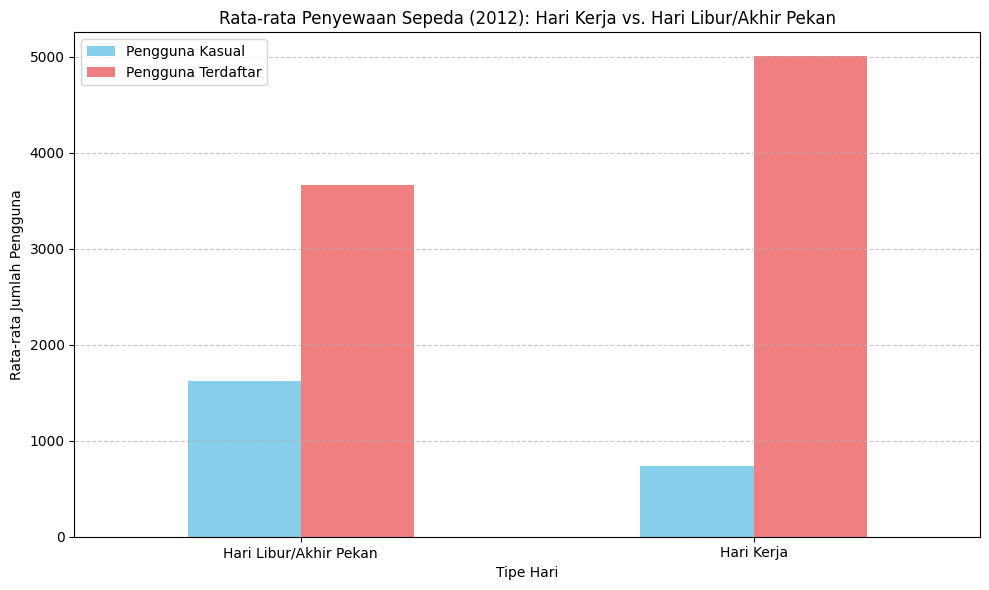

In [70]:
# Visualisasi
fig, ax = plt.subplots(figsize=(10, 6))
rental_patterns.set_index('is_workingday').plot(kind='bar', ax=ax, rot=0, color=['skyblue', 'lightcoral'])

ax.set_title('Rata-rata Penyewaan Sepeda (2012): Hari Kerja vs. Hari Libur/Akhir Pekan')
ax.set_xlabel('Tipe Hari')
ax.set_ylabel('Rata-rata Jumlah Pengguna')
ax.legend(['Pengguna Kasual', 'Pengguna Terdaftar'])
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Pertanyaan 2:

/tmp/ipykernel_1302/3078625740.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='weather_condition_label', y='total_rentals', data=weather_rentals, palette='viridis', ax=ax)


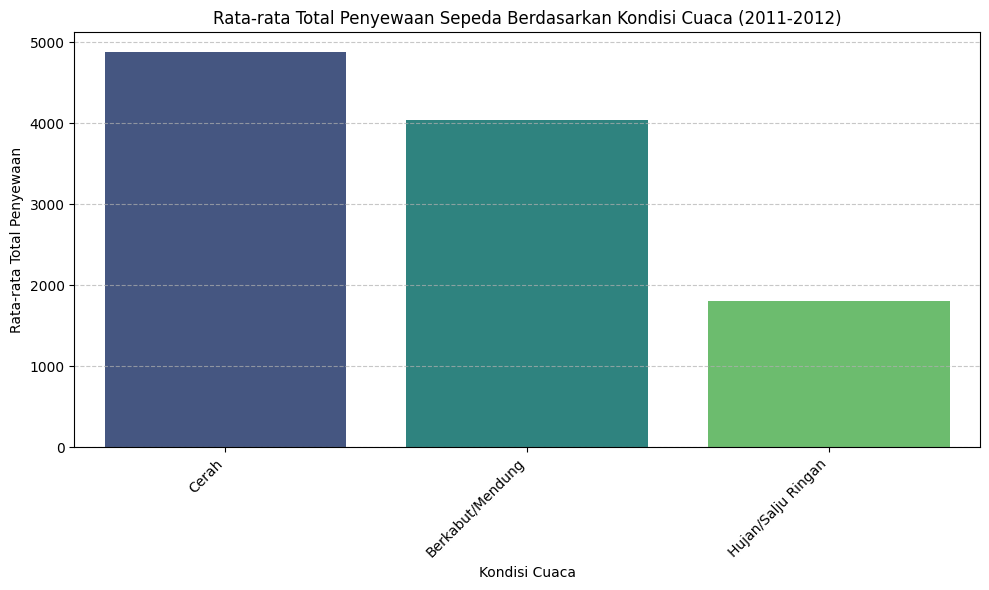

In [71]:
# Visualisasi
weather_labels = {1: 'Cerah', 2: 'Berkabut/Mendung', 3: 'Hujan/Salju Ringan', 4: 'Hujan Deras/Badai'}
weather_rentals['weather_condition_label'] = weather_rentals['weather_condition'].map(weather_labels)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='weather_condition_label', y='total_rentals', data=weather_rentals, palette='viridis', ax=ax)

ax.set_title('Rata-rata Total Penyewaan Sepeda Berdasarkan Kondisi Cuaca (2011-2012)')
ax.set_xlabel('Kondisi Cuaca')
ax.set_ylabel('Rata-rata Total Penyewaan')
plt.xticks(rotation=45, ha='right')
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Pertanyaan 3:

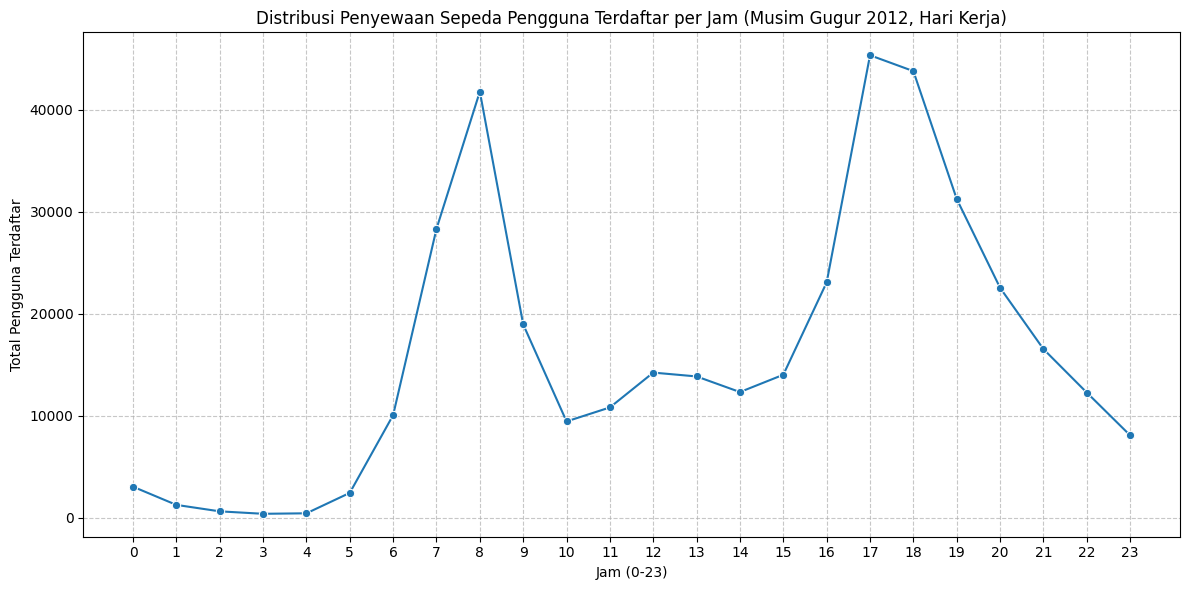

In [72]:
# Visualisasi distribusi penyewaan per jam
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(x='hour', y='registered_users', data=peak_hours, marker='o', ax=ax)

ax.set_title('Distribusi Penyewaan Sepeda Pengguna Terdaftar per Jam (Musim Gugur 2012, Hari Kerja)')
ax.set_xlabel('Jam (0-23)')
ax.set_ylabel('Total Pengguna Terdaftar')
ax.set_xticks(range(0, 24)) # Pastikan semua jam ditampilkan di sumbu X
ax.grid(axis='both', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Penyewaan sepeda didominasi pengguna terdaftar, terutama pada hari kerja, yang mengindikasikan penggunaan untuk komuter, sementara pengguna kasual lebih aktif di akhir pekan untuk rekreasi.
- Cuaca  berpengaruh signifikan, di mana cuaca buruk dapat menurunkan penyewaan hingga 63% dibanding cuaca cerah.
- Pada hari kerja musim gugur 2012, terdapat dua jam puncak penyewaan yaitu pukul 08:00 (berangkat kerja) dan 17:00–18:00 (pulang kerja), dengan sore hari sedikit lebih tinggi.

## Analisis Lanjutan (Opsional)

### Analisis Lanjutan 1: Pola Musiman Pengguna Kasual dan Terdaftar

Rata-rata Penyewaan Sepeda Berdasarkan Musim dan Tahun:


,season,year,casual_users,registered_users,season_label,year_label,season_year
0,1,0,238.055556,1428.611111,Semi,2011,Semi 2011
1,1,1,430.736264,3100.560440,Semi,2012,Semi 2012
2,2,0,843.086957,2932.086957,Panas,2011,Panas 2011
3,2,1,1369.108696,4840.380435,Panas,2012,Panas 2012
4,3,0,1015.425532,3448.936170,Gugur,2011,Gugur 2011
5,3,1,1389.797872,5434.446809,Gugur,2012,Gugur 2012
6,4,0,593.404494,3071.056180,Dingin,2011,Dingin 2011
7,4,1,864.820225,4927.044944,Dingin,2012,Dingin 2012


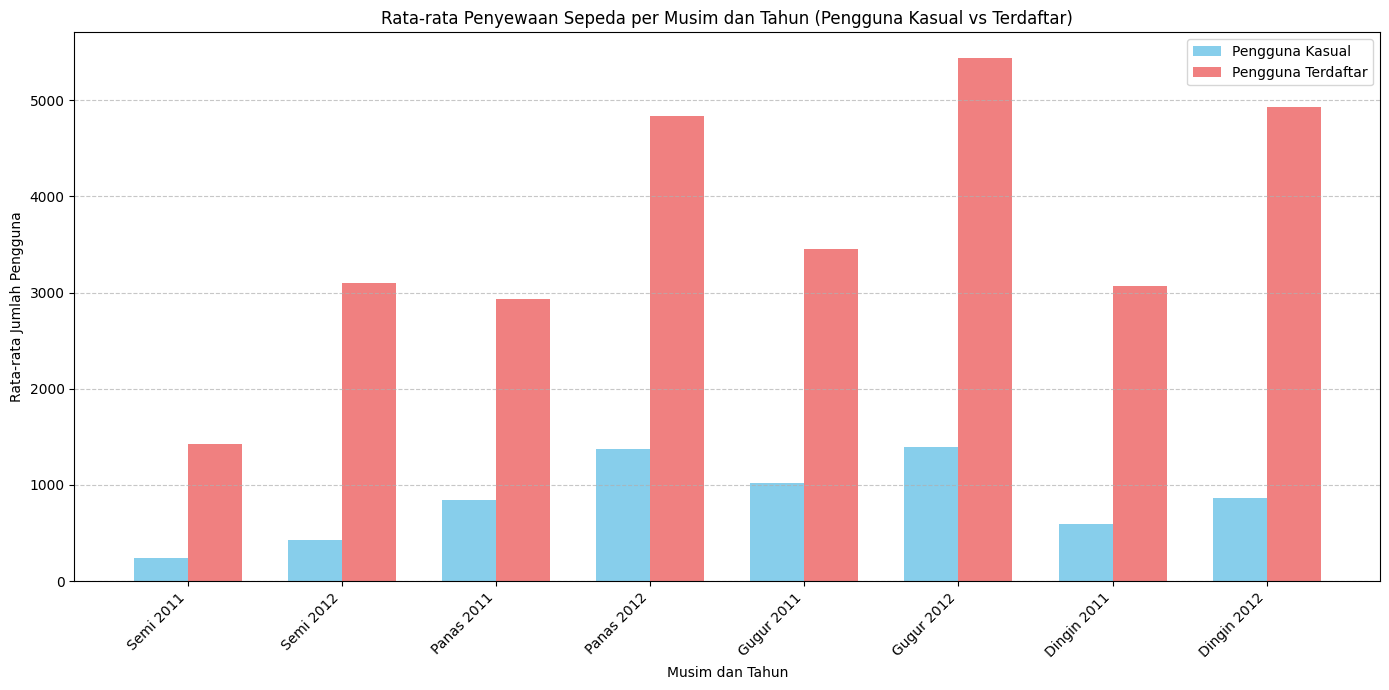

In [73]:
# Kelompokkan data berdasarkan musim dan tahun, lalu hitung rata-rata pengguna kasual dan terdaftar
seasonal_patterns = df_dataday.groupby(['season', 'year'], observed=False)[['casual_users', 'registered_users']].mean().reset_index()

# Ubah nilai 'season' menjadi label yang lebih deskriptif
season_labels = {1: 'Semi', 2: 'Panas', 3: 'Gugur', 4: 'Dingin'}
seasonal_patterns['season_label'] = seasonal_patterns['season'].map(season_labels)

# Ubah nilai 'year' menjadi label yang lebih deskriptif (0=2011, 1=2012)
seasonal_patterns['year_label'] = seasonal_patterns['year'].map({0: 2011, 1: 2012})

# Gabungkan 'season_label' dan 'year_label' untuk sumbu x
seasonal_patterns['season_year'] = seasonal_patterns['season_label'].astype(str) + ' ' + seasonal_patterns['year_label'].astype(str)

print("Rata-rata Penyewaan Sepeda Berdasarkan Musim dan Tahun:")
display(seasonal_patterns)

# Visualisasi
fig, ax = plt.subplots(figsize=(14, 7))

bar_width = 0.35
index = np.arange(len(seasonal_patterns['season_year']))

bar1 = ax.bar(index - bar_width/2, seasonal_patterns['casual_users'], bar_width, label='Pengguna Kasual', color='skyblue')
bar2 = ax.bar(index + bar_width/2, seasonal_patterns['registered_users'], bar_width, label='Pengguna Terdaftar', color='lightcoral')

ax.set_title('Rata-rata Penyewaan Sepeda per Musim dan Tahun (Pengguna Kasual vs Terdaftar)')
ax.set_xlabel('Musim dan Tahun')
ax.set_ylabel('Rata-rata Jumlah Pengguna')
ax.set_xticks(index)
ax.set_xticklabels(seasonal_patterns['season_year'], rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Insight Analisis Lanjutan 1:
- **Pengguna Kasual:** Menunjukkan peningkatan signifikan pada musim **Panas (Summer)** dan **Gugur (Fall)**, terutama di tahun 2012, yang mengindikasikan bahwa mereka lebih sering menyewa sepeda saat cuaca lebih hangat dan menyenangkan untuk rekreasi.
- **Pengguna Terdaftar:** Pola penggunaan mereka lebih stabil sepanjang tahun dibandingkan pengguna kasual, namun tetap menunjukkan sedikit penurunan pada musim **Dingin (Winter)** dan sedikit peningkatan pada musim **Semi (Spring)**, Panas, dan Gugur. Ini menunjukkan bahwa mereka menggunakan sepeda secara lebih konsisten, kemungkinan untuk komuter, meskipun cuaca tetap memengaruhi.
- **Pertumbuhan Tahunan:** Terlihat peningkatan jumlah penyewaan secara keseluruhan dari tahun 2011 ke 2012 untuk kedua jenis pengguna di hampir semua musim, menunjukkan pertumbuhan popularitas layanan sepeda.

## Conclusion & Recommendation

- **Conclusion Pertanyaan 1 (Pola Pengguna):** Pengguna terdaftar (registered users) mendominasi penyewaan sepeda pada hari kerja, menunjukkan penggunaan untuk komuter. Sebaliknya, pengguna kasual (casual users) lebih aktif di hari libur/akhir pekan, kemungkinan untuk tujuan rekreasi. Pola ini konsisten dengan hipotesis bahwa layanan bike sharing melayani kebutuhan transportasi harian dan rekreasi.
- **Conclusion Pertanyaan 2 (Pengaruh Cuaca):** Kondisi cuaca sangat memengaruhi jumlah total penyewaan sepeda. Cuaca hujan/bersalju ringan menyebabkan penurunan signifikan sebesar 63.02% dalam rata-rata penyewaan dibandingkan cuaca cerah. Cuaca buruk yang ekstrem hampir menghentikan aktivitas penyewaan.
- **Conclusion Pertanyaan 3 (Jam Puncak):** Pada hari kerja selama musim gugur tahun 2012, terdapat dua jam puncak penyewaan oleh pengguna terdaftar: sekitar pukul 08:00 (berangkat kerja) dan antara pukul 17:00-18:00 (pulang kerja), dengan puncak sore hari sedikit lebih tinggi.
- **Conclusion Analisis Lanjutan (Pola Musiman):** Pengguna kasual menunjukkan peningkatan signifikan pada musim Panas dan Gugur, terutama di tahun 2012, menandakan preferensi cuaca hangat untuk rekreasi. Pengguna terdaftar memiliki pola yang lebih stabil sepanjang tahun, meskipun sedikit menurun di musim Dingin dan meningkat di musim Semi, Panas, dan Gugur, menunjukkan penggunaan konsisten untuk komuter. Ada pertumbuhan penyewaan secara keseluruhan dari tahun 2011 ke 2012 untuk kedua jenis pengguna.

**Rekomendasi Action Item:**
- **Target Pemasaran Berbasis Pengguna:** Fokuskan kampanye pemasaran untuk pengguna kasual pada musim semi, panas, dan gugur, serta di akhir pekan/hari libur dengan menonjolkan aspek rekreasi. Untuk pengguna terdaftar, promosikan benefit berlangganan atau paket komuter pada hari kerja, terutama di jam-jam puncak (08:00 dan 17:00-18:00).
- **Optimasi Armada Berdasarkan Cuaca:** Tingkatkan ketersediaan dan inspeksi sepeda saat cuaca cerah, terutama pada musim panas dan gugur, untuk memaksimalkan pendapatan. Pertimbangkan untuk menawarkan promosi atau diskon khusus saat cuaca kurang ideal untuk mendorong penggunaan atau alihkan sumber daya ke pemeliharaan.
- **Peningkatan Infrastruktur di Jam Puncak:** Pastikan ketersediaan sepeda yang cukup di stasiun-stasiun populer sekitar jam 08:00 dan 17:00-18:00 pada hari kerja. Pertimbangkan untuk menyediakan lebih banyak stasiun atau opsi pengembalian yang fleksibel di area perkantoran atau transit utama.
- **Strategi untuk Cuaca Buruk:** Selama musim dingin atau periode cuaca buruk, tawarkan insentif khusus atau promosi untuk mempertahankan pengguna. Siapkan strategi komunikasi yang jelas mengenai kondisi operasional saat cuaca ekstrem.

In [74]:
# Menyimpan data yang sudah dibersihkan
df_datahour.to_csv('main_data.csv', index=False)

print("File main_data.csv berhasil disimpan!")

File main_data.csv berhasil disimpan!
